In [1]:
import pdal
import pystac_client
import planetary_computer
import PIL
import pyproj

(PDAL Error) Can't load library /Users/sala6791/PDAL/.pixi/envs/goldendoodle/lib/libpdal_plugin_reader_hdf.dylib: Failed to load "/Users/sala6791/PDAL/.pixi/envs/goldendoodle/lib/libpdal_plugin_reader_hdf.dylib": dlopen(/Users/sala6791/PDAL/.pixi/envs/goldendoodle/lib/libpdal_plugin_reader_hdf.dylib, 0x0002): Library not loaded: @rpath/libhdf5_cpp.320.dylib
  Referenced from: <3556841C-EDE8-3560-B617-381AF0E87C21> /Users/sala6791/PDAL/.pixi/envs/goldendoodle/lib/libpdal_plugin_reader_hdf.20.2.0.dylib
  Reason: tried: '/Users/sala6791/PDAL/.pixi/envs/goldendoodle/lib/libhdf5_cpp.320.dylib' (no such file), '/Users/sala6791/PDAL/.pixi/envs/goldendoodle/lib/libhdf5_cpp.320.dylib' (no such file), '/Users/sala6791/PDAL/.pixi/envs/goldendoodle/lib/libhdf5_cpp.320.dylib' (no such file), '/Users/sala6791/PDAL/.pixi/envs/goldendoodle/bin/../lib/libhdf5_cpp.320.dylib' (no such file), '/usr/local/lib/libhdf5_cpp.320.dylib' (no such file), '/usr/lib/libhdf5_cpp.320.dylib' (no such file, not in dyld

In [2]:
# Estimate our UTM zone
from pyproj import CRS
from pyproj.aoi import AreaOfInterest
from pyproj.database import query_utm_crs_info

def get_utm(point):
    longitude, latitude = point.x, point.y
    buffer = 0.001
    utm_crs_list = query_utm_crs_info(
        datum_name="WGS 84",
        area_of_interest=AreaOfInterest(
            west_lon_degree=longitude - buffer,
            south_lat_degree=latitude - buffer,
            east_lon_degree=longitude + buffer,
            north_lat_degree=latitude + buffer,
        ),
    )
    utm_crs = CRS.from_epsg(utm_crs_list[0].code)
    return utm_crs

In [11]:
# The Bean
bean = {"type": "Point", "coordinates": [-87.623358, 41.8826812]}

from shapely.geometry import shape
from shapely.ops import transform

geom = shape(bean)

utm = get_utm(geom)

wgs84 = pyproj.CRS("EPSG:4326")

project_dd_to_utm = pyproj.Transformer.from_crs(wgs84, utm, always_xy=True).transform
project_utm_to_dd = pyproj.Transformer.from_crs(utm, wgs84, always_xy=True).transform

utm_point = transform(project_dd_to_utm, geom)
window = utm_point.buffer(100)

window_dd = transform(project_utm_to_dd, window)

import geopandas

df = geopandas.GeoDataFrame(geometry=[window_dd], crs="EPSG:4326")

df.explore()

In [12]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

search = catalog.search(collections=["3dep-lidar-copc"], intersects=window_dd)
ic = search.get_all_items()

/Users/sala6791/PDAL/.pixi/envs/goldendoodle/lib/python3.13/site-packages/pystac_client/item_search.py:940: FutureWarning: get_all_items() is deprecated, use item_collection() instead.
  warnings.warn(


In [13]:
ic

In [14]:
OUTPUT_RESOLUTION = 2.0
READ_RESOLUTION = 2.0
polygon = window.wkt + f" / EPSG:{utm.to_epsg()}"

In [15]:
readers = []
for tile in ic:
    url = tile.assets["data"].href
    reader = pdal.Reader.copc(
        url, requests=3, resolution=READ_RESOLUTION, polygon=polygon
    )
    readers.append(reader)

In [16]:
assign = pdal.Filter.assign(value=["Intensity = Intensity / 256"])


In [17]:
writer = pdal.Writer.gdal(
    "intensity.tif",
    resolution=OUTPUT_RESOLUTION,
    dimension="Intensity",
    data_type="uint8",
    output_type="mean",
)

In [18]:
pipeline = None

# Gather up all of our readers and concatenate them together
for reader in readers:
    if not pipeline:
        pipeline = reader
    else:
        pipeline = pipeline | reader

pipeline = pipeline | assign | writer

In [19]:
%%time

# Use streaming mode at 1e6 points at a time. This
# helps us conserve memory for pipelines that are streamable
# check that with the pipeline.streamable property
results = pipeline.execute_streaming(chunk_size=1000000)
print(pipeline.log)

# the last stage of our pipeline is the writer, and the 'dimension'
# option on the writer is what we want to print
dimension = pipeline.stages[-1].options["dimension"]
print(f"Number of points returned for dimension {dimension}: {results}")


Number of points returned for dimension Intensity: 62548
CPU times: user 702 ms, sys: 56 ms, total: 758 ms
Wall time: 10.8 s


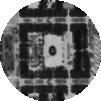

In [20]:
PIL.Image.open("intensity.tif")


In [21]:
# Gather up all of our readers and concatenate them together
pipeline = None

# Gather up all of our readers and concatenate them together
for reader in readers:
    if not pipeline:
        pipeline = reader
    else:
        pipeline = pipeline | reader

merge = pdal.Filter.merge()
hag = pdal.Filter.hag_nn()
writer = pdal.Writer.gdal(
    "hag.tif",
    resolution=OUTPUT_RESOLUTION,
    dimension="HeightAboveGround",
    data_type="float32",
    output_type="mean",
)


pipeline = pipeline | merge | hag | writer

p = pipeline.execute()

In [22]:
colorramp = """-10.18599987030029297,247,251,255,255,-10.1860
-0.00115290172120908,228,239,249,255,-0.0012
0.17222511302108146,209,226,243,255,0.1722
0.6745767967615599,186,214,235,255,0.6746
1.70373090991130027,154,200,224,255,1.7037
3.80649503742675499,115,178,216,255,3.8065
6.60277122391136828,82,157,204,255,6.6028
13.59346169012289351,53,133,191,255,13.5935
35.1501281897475053,29,108,177,255,35.1501
68.49649969184777376,8,81,156,255,68.4965
347.23944590611102967,8,48,107,255,347.2394"""
with open("hag-colors.txt", "w") as f:
    f.write(colorramp)


In [ ]:
%%bash
gdaldem color-relief hag.tif hag-colors.txt hag.tif


0...10...20...30...40...50...60...70...80...90...100 - done.


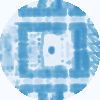

In [24]:

# Display the HAG
PIL.Image.open("hag.tif")